              datetime  Month  Day  Season  Season_Winter  Season_Summer  \
0  2021-01-01 12:00:00    0.0  0.0  Winter            1.0            0.0   
1  2021-01-01 13:00:00    0.0  0.0  Winter            1.0            0.0   
2  2021-01-01 14:00:00    0.0  0.0  Winter            1.0            0.0   
3  2021-01-01 15:00:00    0.0  0.0  Winter            1.0            0.0   
4  2021-01-01 16:00:00    0.0  0.0  Winter            1.0            0.0   

   Season_Monsoon      temp       dew  humidity  precip  windgust  windspeed  \
0             0.0  0.261905  0.394737  0.566894     0.0  0.171717   0.119874   
1             0.0  0.309524  0.342105  0.422701     0.0  0.217172   0.119874   
2             0.0  0.335714  0.439474  0.516868     0.0  0.227273   0.167192   
3             0.0  0.333333  0.342105  0.393694     0.0  0.222222   0.176656   
4             0.0  0.309524  0.342105  0.422701     0.0  0.199495   0.176656   

    winddir  cloudcover  visibility  updated visibility   PM2.

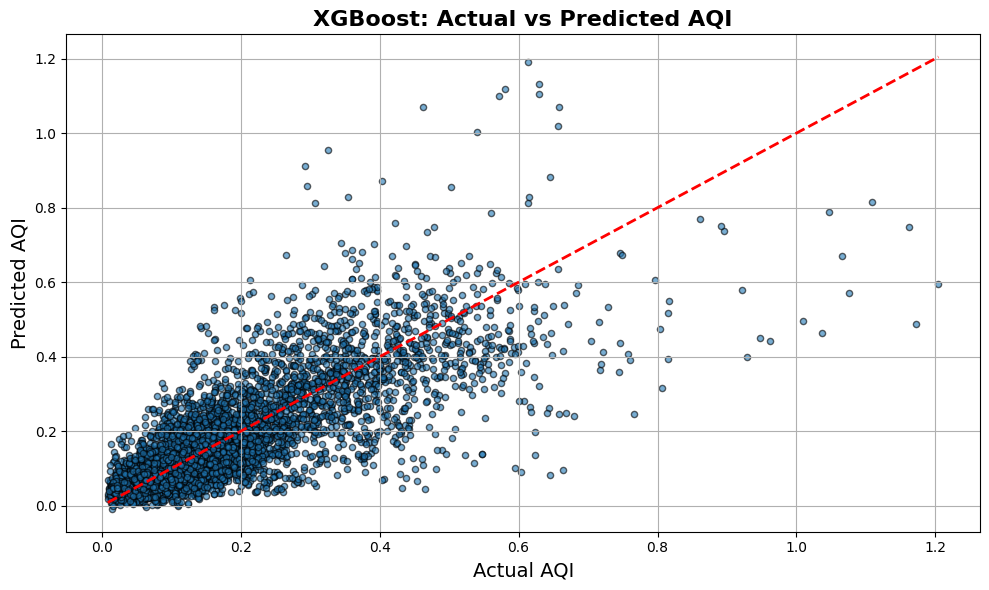

In [ ]:
# importing libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from datetime import datetime
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Loading the CSV Dataset
df = pd.read_csv("preprocessed_dataset.csv")
pd.set_option('display.max_columns', None)
print(df.head())

# Handlling missing values
df.ffill(inplace=True)  # Forward fill (updated method)
df.fillna(0, inplace=True)  # Fill remaining NaN with 0

# Compute AQI (CPCB Formula - Simplified Example)
def calculate_aqi(row):
    # Sub-index calculation for PM2.5 (example breakpoints)
    pm25 = row['PM2.5 (µg/m³)']
    if pm25 <= 30: return pm25 * 50 / 30
    elif pm25 <= 60: return 50 + (pm25 - 30) * 50 / 30
    elif pm25 <= 90: return 100 + (pm25 - 60) * 100 / 30
    elif pm25 <= 120: return 200 + (pm25 - 90) * 100 / 30
    elif pm25 <= 250: return 300 + (pm25 - 120) * 100 / 130
    else: return 400 + (pm25 - 250) * 100 / 250
    # Add other pollutants (PM10, NO2, etc.) and take max in full implementation

df['AQI'] = df.apply(calculate_aqi, axis=1)

# Selecting features to scale
features_to_scale = [
    "temp", "dew", "humidity", "precip", "windgust", "windspeed", "winddir",
    "cloudcover", "visibility", "PM10 (µg/m³)", "NO (µg/m³)", "NO2 (µg/m³)", "NOx (ppb)",
    "NH3 (µg/m³)", "SO2 (µg/m³)", "CO (µg/m³)", "Ozone (µg/m³)", "Benzene (µg/m³)",
    "Toluene (µg/m³)", "Xylene (µg/m³)", "PM2.5_lag_1h", "PM2.5_lag_3h",
    "PM2.5_lag_6h", "PM2.5_lag_12h", "PM2.5_ma_3h", "PM2.5_ma_6h", "PM2.5_ma_12h"
]

scaler = MinMaxScaler(feature_range=(0, 1))
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Ensure 'datetime' column is in datetime format
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Extract hour and convert to cyclical features
df["hour"] = df["datetime"].dt.hour
df["Hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df.drop(["hour"], axis=1, inplace=True)

# Time-based split: before 2024 → train+val, 2024 → test
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
train_val_df = df[df["datetime"].dt.year < 2024].copy()
test_df = df[df["datetime"].dt.year == 2024].copy()

# Extract features and target
feature_columns = [col for col in df.columns if col not in ["datetime", "PM2.5 (µg/m³)", "AQI", "Season"]]
X_trainval = train_val_df[feature_columns].values
y_trainval = train_val_df["AQI"].values
X_test = test_df[feature_columns].values
y_test = test_df["AQI"].values

# Split train_val into training and validation (approx. 70% train, 15% val from total)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1765, random_state=42, shuffle=False)  # preserve temporal order

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

print(df["datetime"].head())  # Check the first few entries
print(df["datetime"].dt.year.unique())  # Check the unique years

# Creating sequences for time-series prediction (24-hour window)
sequence_length = 24

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)

print(f"Train shape: {X_train_seq.shape}, Validation shape: {X_val_seq.shape}, Test shape: {X_test_seq.shape}")

# Converting to float32 (all features are numeric now)
X_train_seq = X_train_seq.astype(np.float32)
X_val_seq = X_val_seq.astype(np.float32)
X_test_seq = X_test_seq.astype(np.float32)
y_train_seq = y_train_seq.astype(np.float32)
y_val_seq = y_val_seq.astype(np.float32)
y_test_seq = y_test_seq.astype(np.float32)

# Building LSTM Model
def build_lstm_model(lstm_units, learning_rate, dropout_rate):
    lstm_units = int(lstm_units)

    model = Sequential([
        Input(shape=(sequence_length, X_train_seq.shape[2])),  # Define input shape here
        LSTM(units=lstm_units, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(units=lstm_units),
        Dropout(dropout_rate),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    return model

# Grey Wolf Optimization (GWO)
class GrayWolfOptimizer:
    def __init__(self, obj_function, num_wolves=5, max_iter=10, bounds=None):
        self.obj_function = obj_function
        self.num_wolves = num_wolves
        self.max_iter = max_iter
        self.bounds = np.array(bounds)

    def optimize(self):
        wolves = np.random.uniform(self.bounds[:, 0], self.bounds[:, 1], (self.num_wolves, len(self.bounds)))
        scores = np.array([self.obj_function(wolf) for wolf in wolves])
        alpha_idx = np.argmin(scores)
        alpha = wolves[alpha_idx]

        for t in range(self.max_iter):
            a = 2 - t * (2 / self.max_iter)  # Linearly decrease a from 2 to 0
            for i in range(self.num_wolves):
                A = 2 * a * np.random.rand(len(self.bounds)) - a
                C = 2 * np.random.rand(len(self.bounds))
                D = np.abs(C * alpha - wolves[i])
                wolves[i] = alpha - A * D
                wolves[i] = np.clip(wolves[i], self.bounds[:, 0], self.bounds[:, 1])

            scores = np.array([self.obj_function(wolf) for wolf in wolves])
            alpha_idx = np.argmin(scores)
            alpha = wolves[alpha_idx]
            print(f"Iteration {t + 1}: Best Score = {scores[alpha_idx]}")

        return alpha

# Objective function for GWO
def objective_function(params):
    lstm_units, learning_rate, dropout_rate = int(params[0]), params[1], params[2]
    model = build_lstm_model(lstm_units, learning_rate, dropout_rate)
    early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=10, batch_size=32, verbose=0, callbacks=[early_stopping]
    )
    return history.history["val_loss"][-1]

# Set bounds and run GWO (Reduced to optimize runtime)
bounds = [
    [16, 64],         # LSTM units (reduced upper bound from 128 to 64)
    [0.001, 0.01],    # Learning rate (narrowed range for faster convergence)
    [0.1, 0.4]        # Dropout rate (slightly narrowed)
]

# Reduce number of wolves and iterations
gwo = GrayWolfOptimizer(
    obj_function=objective_function,
    num_wolves=3,       # Reduced from 5
    max_iter=5,         # Reduced from 10
    bounds=bounds
)

best_params = gwo.optimize()

best_lstm_units = int(best_params[0])
best_learning_rate = best_params[1]
best_dropout_rate = best_params[2]

print(f"Best Hyperparameters: LSTM Units = {best_lstm_units}, Learning Rate = {best_learning_rate}, Dropout Rate = {best_dropout_rate}")

# Training final LSTM model
final_model = build_lstm_model(best_lstm_units, best_learning_rate, best_dropout_rate)
history = final_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50, batch_size=32, verbose=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
)

from sklearn.metrics import mean_absolute_percentage_error

# Evaluate final model
y_pred = final_model.predict(X_test_seq)
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
mae = mean_absolute_error(y_test_seq, y_pred)
r2 = r2_score(y_test_seq, y_pred)
mape = mean_absolute_percentage_error(y_test_seq, y_pred)

print(f"LSTM+GWO - RMSE: {rmse}, MAE: {mae}, R²: {r2}, MAPE: {mape * 100}%")

print(f"y_test shape: {y_test.shape}")
print(f"y_pred shape: {y_pred.shape}")

min_len = min(len(y_test), len(y_pred))
y_test = y_test[:min_len]
y_pred = y_pred[:min_len]

print(f"X_train shape: {X_train_seq.shape}")
print(f"X_test shape: {X_test_seq.shape}")

# Scatter Plot (AQI) - High Resolution 600 dpi
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k', s=20)  # s=20 to make points slightly bigger
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2)  # Diagonal perfect line

# Set Titles and Labels
plt.xlabel("Actual AQI", fontsize=14)
plt.ylabel("Predicted AQI", fontsize=14)
plt.title("Hybrid: Actual vs Predicted AQI", fontsize=16, fontweight='bold')
plt.grid(True)

# Save directly as High-Resolution TIFF (600 dpi)
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted_aqi.tiff', format='tiff', dpi=600)

# Optional: Show plot (to see in notebook)
plt.show()


In [ ]:
from google.colab import files
files.download('scatter_actual_vs_predicted_aqi.tiff')


SyntaxError: unterminated string literal (detected at line 2) (<ipython-input-2-35c414542116>, line 2)

In [ ]:
from PIL import Image

# Open the TIFF file
image = Image.open('_visibility_missing_values_comparison_.tiff')

# Save as PDF
image.save('your_image.pdf', 'PDF', resolution=600.0)
